PART II-Data analysis, ML & NN models
=====================================

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
# Load the dataset
file_path = "../data/Crime_Incidents_20250205.csv"
df = pd.read_csv(file_path)
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318735 entries, 0 to 318734
Data columns (total 31 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Case Number              318735 non-null  object 
 1   Incident Datetime        318735 non-null  object 
 2   Incident ID              0 non-null       float64
 3   Incident Type Primary    318735 non-null  object 
 4   Incident Description     318735 non-null  object 
 5   Parent Incident Type     318735 non-null  object 
 6   Hour of Day              318735 non-null  int64  
 7   Day of Week              318735 non-null  object 
 8   Address                  318697 non-null  object 
 9   City                     318735 non-null  object 
 10  State                    318735 non-null  object 
 11  Location                 312175 non-null  object 
 12  Latitude                 317454 non-null  object 
 13  Longitude                317454 non-null  object 
 14  Crea

In [ ]:
print(df.describe())

       Incident ID    Hour of Day  updated_at
count          0.0  318735.000000         0.0
mean           NaN      11.923526         NaN
std            NaN       7.194515         NaN
min            NaN       0.000000         NaN
25%            NaN       6.000000         NaN
50%            NaN      13.000000         NaN
75%            NaN      18.000000         NaN
max            NaN      23.000000         NaN


In [ ]:
df.isnull().sum()

,0
Case Number,0
Incident Datetime,0
Incident ID,318735
Incident Type Primary,0
Incident Description,0
Parent Incident Type,0
Hour of Day,0
Day of Week,0
Address,38
City,0


In [ ]:
drop_col = ['Incident ID', 'updated_at', 'Created At'] # dropping irrelavant fields with large missing values
df.drop(columns=drop_col, inplace=True, errors='ignore')

df.dropna(subset=['Location','Address', 'Council District'], inplace=True) #dropping rows
df.isnull().sum()

,0
Case Number,0
Incident Datetime,0
Incident Type Primary,0
Incident Description,0
Parent Incident Type,0
Hour of Day,0
Day of Week,0
Address,0
City,0
State,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 312078 entries, 0 to 318734
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Case Number              312078 non-null  object
 1   Incident Datetime        312078 non-null  object
 2   Incident Type Primary    312078 non-null  object
 3   Incident Description     312078 non-null  object
 4   Parent Incident Type     312078 non-null  object
 5   Hour of Day              312078 non-null  int64 
 6   Day of Week              312078 non-null  object
 7   Address                  312078 non-null  object
 8   City                     312078 non-null  object
 9   State                    312078 non-null  object
 10  Location                 312078 non-null  object
 11  Latitude                 312078 non-null  object
 12  Longitude                312078 non-null  object
 13  zip_code                 312078 non-null  object
 14  neighborhood             

In [ ]:
df['Incident Datetime'] = pd.to_datetime(df['Incident Datetime'], errors='coerce') #
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 312078 entries, 0 to 318734
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Case Number              312078 non-null  object        
 1   Incident Datetime        312078 non-null  datetime64[ns]
 2   Incident Type Primary    312078 non-null  object        
 3   Incident Description     312078 non-null  object        
 4   Parent Incident Type     312078 non-null  object        
 5   Hour of Day              312078 non-null  int64         
 6   Day of Week              312078 non-null  object        
 7   Address                  312078 non-null  object        
 8   City                     312078 non-null  object        
 9   State                    312078 non-null  object        
 10  Location                 312078 non-null  object        
 11  Latitude                 312078 non-null  float64       
 12  Longitude            

,Case Number,Incident Datetime,Incident Type Primary,Incident Description,Parent Incident Type,Hour of Day,Day of Week,Address,City,State,...,Census Block Group,Census Block,2010 Census Tract,2010 Census Block Group,2010 Census Block,Police District,TRACTCE20,GEOID20_tract,GEOID20_blockgroup,GEOID20_block
0,16-1660403,2016-06-14 01:20:00,ASSAULT,ASSAULT,Assault,1,Tuesday,E AMHERST ST & E AMHERST ST,Buffalo,NY,...,2,2003,55,2,2005,District D,005500,36029005500,360290001102,360290170002003
1,16-3480266,2016-12-13 05:00:00,LARCENY/THEFT,LARCENY/THEFT,Theft,5,Tuesday,1000 Block E LOVEJOY ST,Buffalo,NY,...,4,4001,23,4,4001,District C,002300,36029002300,360290002004,360290034004001
3,14-3210732,2014-11-17 08:08:00,LARCENY/THEFT,LARCENY/THEFT,Theft,8,Monday,2100 Block ELMWOOD AV,Buffalo,NY,...,2,2007,56,2,2008,District D,005600,36029005600,360290001102,360290163002007
4,15-1100268,2015-04-20 10:22:00,LARCENY/THEFT,LARCENY/THEFT,Theft,10,Monday,2100 Block ELMWOOD AV,Buffalo,NY,...,2,2007,56,2,2008,District D,005600,36029005600,360290001102,360290163002007
5,15-1000814,2015-04-10 03:00:00,BURGLARY,BURGLARY,Breaking & Entering,3,Friday,400 Block GLENWOOD AV,Buffalo,NY,...,3,3009,33.02,3,3011,District C,003302,36029003302,360290001103,360290011003009


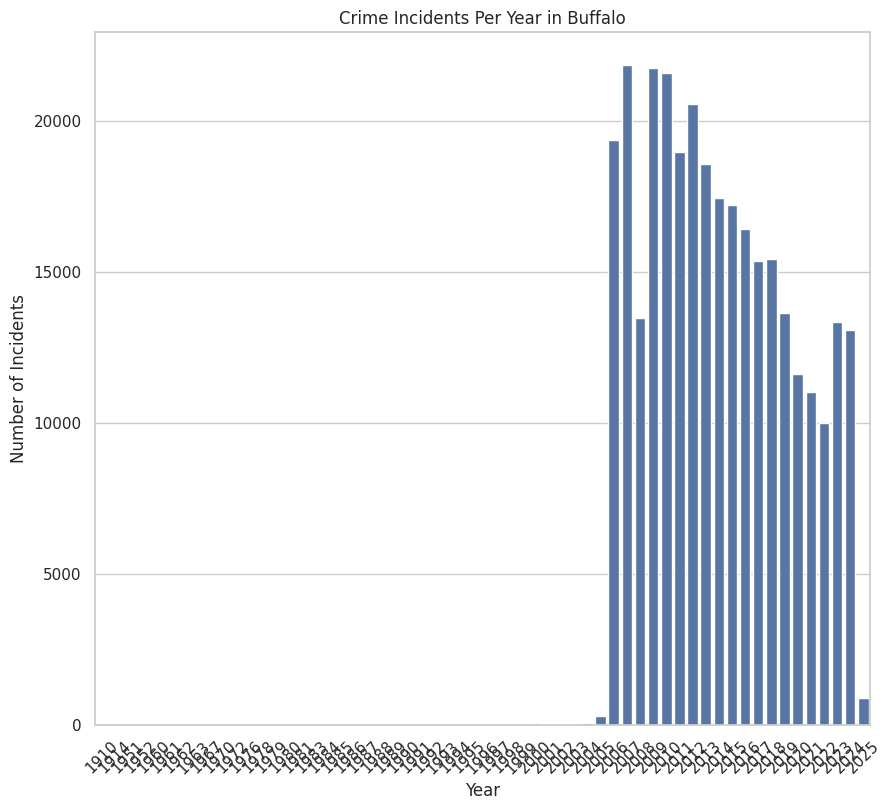

In [ ]:


sns.set(style="whitegrid")
# Plot of Crimes per Year
df['Year'] = df['Incident Datetime'].dt.year
plt.figure(figsize=(10, 9))
sns.countplot(x=df['Year'])
plt.xticks(rotation=45)
plt.title("Crime Incidents Per Year in Buffalo")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.show()


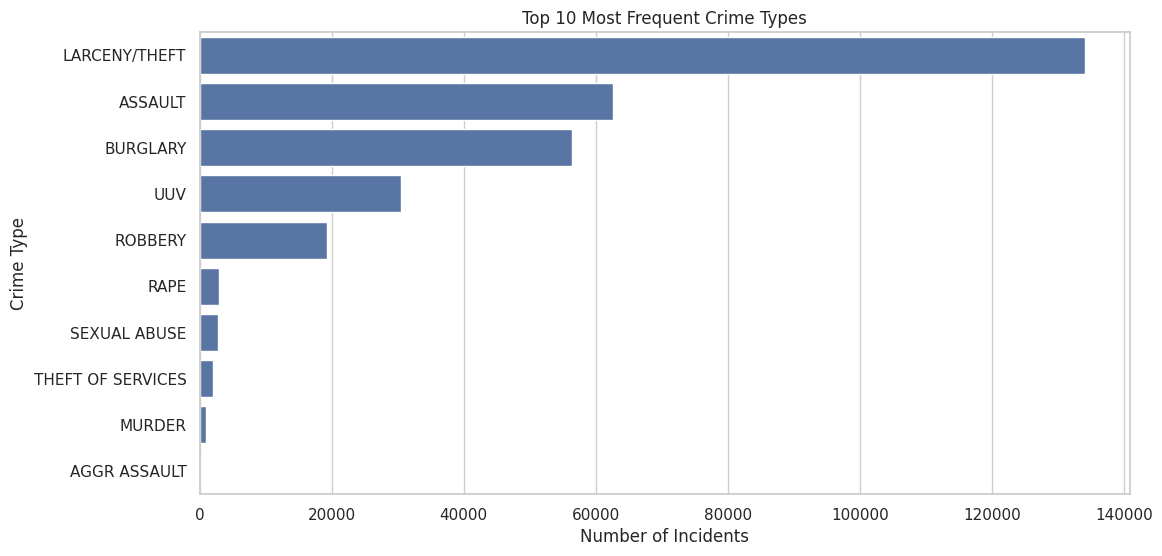

In [ ]:
# Plot of Most common crime types
plt.figure(figsize=(12, 6))
top_crimes = df['Incident Type Primary'].value_counts().nlargest(10)
sns.barplot(x=top_crimes.values, y=top_crimes.index)
plt.title("Top 10 Most Frequent Crime Types")
plt.xlabel("Number of Incidents")
plt.ylabel("Crime Type")
plt.show()

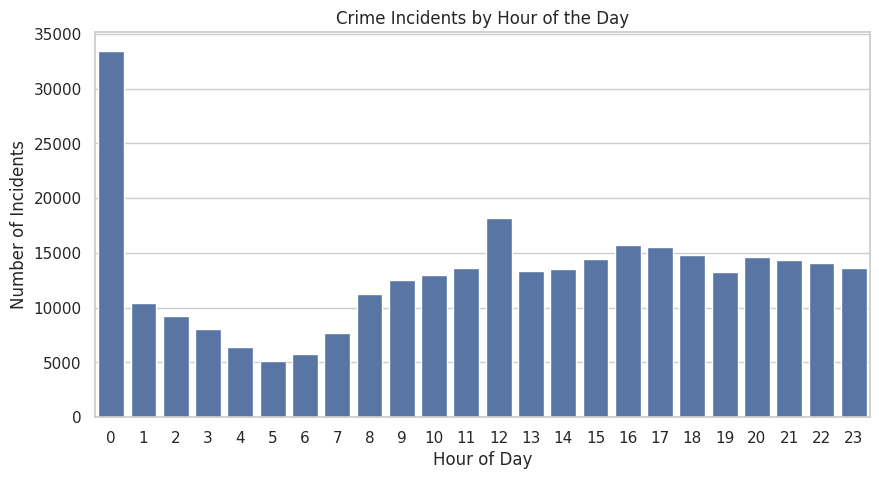

In [ ]:
# Plot of Hourly crime trends
plt.figure(figsize=(10, 5))
sns.countplot(x=df['Hour of Day'])
plt.title("Crime Incidents by Hour of the Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Incidents")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
# Initializing the encoder
enc = LabelEncoder()

# Applying Label Encoding to the categorical columns
df['Incident Type Primary'] = enc.fit_transform(df['Incident Type Primary'])
df['Incident Description'] = enc.fit_transform(df['Incident Description'])
df['Parent Incident Type'] = enc.fit_transform(df['Parent Incident Type'])
df['neighborhood'] = enc.fit_transform(df['neighborhood'])
df['zip_code'] = enc.fit_transform(df['zip_code'])
df['Council District'] = enc.fit_transform(df['Council District'])

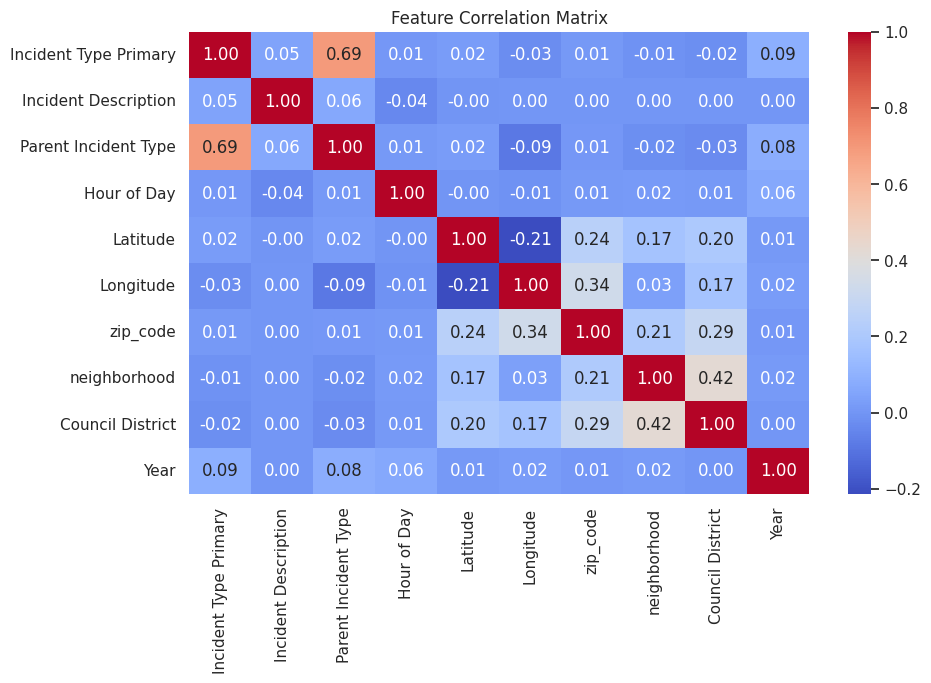

In [ ]:
numerical_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10, 6))
# Calculating correlation only on numerical columns
corr_matrix = numerical_df.corr()  # df.corr() to numerical_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()



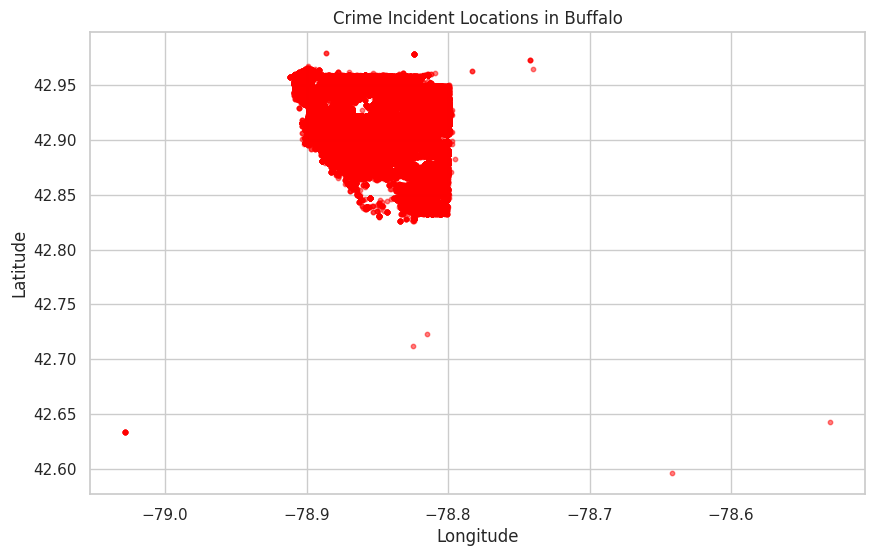

In [ ]:
#scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.5, c='red', s=10)  # Small dots for better visualization
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Crime Incident Locations in Buffalo")
plt.grid(True)
plt.show()

In [ ]:
day_of_week_map = {         # Mapping days of the week to numerical values
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
    'Friday': 4, 'Saturday': 5, 'Sunday': 6
}
# Applying mapping to the column
df['Day of Week'] = df['Day of Week'].map(day_of_week_map)
print(df[['Day of Week']].head())


   Day of Week
0            1
1            1
3            0
4            0
5            4


In [ ]:
features = ['Hour of Day', 'Day of Week', 'Parent Incident Type', 'Latitude', 'Longitude', 'neighborhood'] #selecting relevant features.
target = 'Incident Type Primary'

X = df[features]
y = df[target]

class_counts = y.value_counts()
rare_classes = class_counts[class_counts == 1].index
df_filtered = df[~df[target].isin(rare_classes)]
X = df_filtered[features]
y = df_filtered[target]

# Spliting dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# spliting the training dataset set into training and validation sets (80% train, 20% validation)
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Print the shapes of all datasets
print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)
print("Validation set:", X_validation.shape, y_validation.shape)

Training set: (199728, 6) (199728,)
Test set: (62416, 6) (62416,)
Validation set: (49932, 6) (49932,)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model1 = LogisticRegression(max_iter=500)
model1.fit(X_train_scaled, y_train)
y_pred1 = model1.predict(X_test_scaled)
acc1 = accuracy_score(y_test, y_pred1)
print("Logistic Regression Accuracy:", acc1)


Logistic Regression Accuracy: 0.9103274801332991


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

acc2 = accuracy_score(y_test, y_pred2)
print("Random Forest Accuracy:", acc2)


Random Forest Accuracy: 0.9748461932837734


In [ ]:
from sklearn.naive_bayes import GaussianNB
model3 = GaussianNB()
model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)

acc3 = accuracy_score(y_test, y_pred3)
print("Naïve Bayes Accuracy:", acc3)


Naïve Bayes Accuracy: 0.9014515508843887


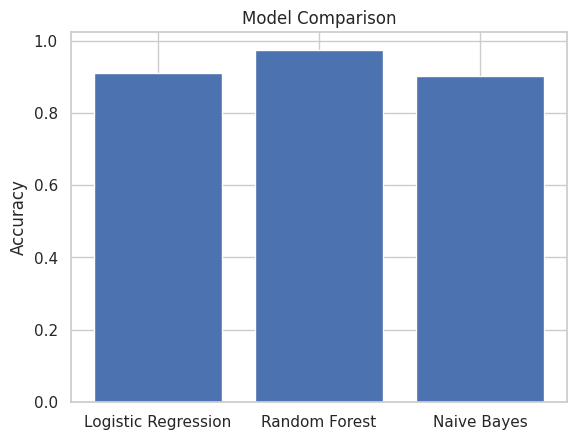

In [ ]:
models = ['Logistic Regression', 'Random Forest', 'Naive Bayes']
accuracies = [acc1, acc2, acc3]
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()


In [ ]:
# Checking for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Applying Label Encoding to the target variable after filtering
tar_encoder = LabelEncoder()
y_train = tar_encoder.fit_transform(y_train)  # Fit and transform y_train
y_test = tar_encoder.transform(y_test)  # Transform y_test using the same encoder

num_classes = len(tar_encoder.classes_)
# Converting data to PyTorch tensors and moving to device
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

# Creating DataLoader
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Defining the Neural Network Model
class Crime_NN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Crime_NN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return self.softmax(x)

# Model parameters
input_size = X_train.shape[1]
hidden_size = 32
output_size = len(tar_encoder.classes_)

# Initializing model and move to device
model = Crime_NN(input_size, hidden_size, output_size).to(device)
# Defining the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)  # Move data to GPU
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}")

# Evaluating the model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)  # Moving data to GPU
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Neural Network Test Accuracy: {accuracy:.4f}")


Using device: cuda
Epoch [1/20], Loss: 15315.4970
Epoch [2/20], Loss: 14874.3119
Epoch [3/20], Loss: 14439.7066
Epoch [4/20], Loss: 14150.5055
Epoch [5/20], Loss: 14147.3985
Epoch [6/20], Loss: 14143.7895
Epoch [7/20], Loss: 14143.4759
Epoch [8/20], Loss: 14141.4812
Epoch [9/20], Loss: 14141.2425
Epoch [10/20], Loss: 14141.4493
Epoch [11/20], Loss: 13891.9776
Epoch [12/20], Loss: 13766.1040
Epoch [13/20], Loss: 13765.9992
Epoch [14/20], Loss: 13765.4507
Epoch [15/20], Loss: 13765.2820
Epoch [16/20], Loss: 13765.2468
Epoch [17/20], Loss: 13762.2829
Epoch [18/20], Loss: 13720.7056
Epoch [19/20], Loss: 13720.3217
Epoch [20/20], Loss: 13720.2295
Neural Network Test Accuracy: 0.8796


In [ ]:
# Defining the path to save the model
model_path = "a0_part2.pth"

# Saving the model weights
torch.save(model.state_dict(), model_path)
